# Project 4 Notebook: Chocolate Sales Dataset (2023–2024)

This notebook presents the first three stages of an end-to-end data science workflow based on the Kaggle *Chocolate Sales Dataset (2023–2024)*.

It includes:

1. **Data Acquisition & Preparation**  
   Load and merge multiple CSV files, clean the data, and construct a unified dataset.

2. **Exploratory Data Analysis (EDA)**  
   Analyze distributions, trends, and relationships, and apply unsupervised learning to uncover hidden patterns.

3. **Feature Engineering & Preprocessing**  
   Create new features, handle missing values, encode categorical variables, and scale numerical features to prepare for modeling.


## 1. Data Acquisition & Preparation

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("./data")

In [ ]:
# Load all CSV files into separate DataFrames
sales = pd.read_csv(DATA_DIR / "sales.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
stores = pd.read_csv(DATA_DIR / "stores.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv")
calendar = pd.read_csv(DATA_DIR / "calendar.csv")

print("sales:", sales.shape)
print("products:", products.shape)
print("stores:", stores.shape)
print("customers:", customers.shape)
print("calendar:", calendar.shape)

sales: (1000000, 11)
products: (200, 6)
stores: (100, 5)
customers: (50000, 5)
calendar: (731, 6)


In [ ]:
# Function to summarize each table
def summarize(df, name):
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    print("Missing values:")
    print(df.isna().sum())
    display(df.head(3))

summarize(sales, "sales")
summarize(products, "products")
summarize(stores, "stores")
summarize(customers, "customers")
summarize(calendar, "calendar")


sales
----------------------------------------
Shape: (1000000, 11)
Missing values:
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75



products
----------------------------------------
Shape: (200, 6)
Missing values:
product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120



stores
----------------------------------------
Shape: (100, 5)
Missing values:
store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall



customers
----------------------------------------
Shape: (50000, 5)
Missing values:
customer_id       0
age               0
gender            0
loyalty_member    0
join_date         0
dtype: int64


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13



calendar
----------------------------------------
Shape: (731, 6)
Missing values:
date           0
year           0
month          0
day            0
week           0
day_of_week    0
dtype: int64


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1


In [ ]:
# Data cleaning

# 1. Standardize column names
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

sales = clean_columns(sales)
products = clean_columns(products)
stores = clean_columns(stores)
customers = clean_columns(customers)
calendar = clean_columns(calendar)

# 2. Convert date columns to datetime format
sales["order_date"] = pd.to_datetime(sales["order_date"])
customers["join_date"] = pd.to_datetime(customers["join_date"])
calendar["date"] = pd.to_datetime(calendar["date"])

# 3. Check for duplicate rows
print("Duplicate rows in sales:", sales.duplicated().sum())
print("Duplicate rows in products:", products.duplicated().sum())
print("Duplicate rows in stores:", stores.duplicated().sum())
print("Duplicate rows in customers:", customers.duplicated().sum())
print("Duplicate rows in calendar:", calendar.duplicated().sum())

Duplicate rows in sales: 0
Duplicate rows in products: 0
Duplicate rows in stores: 0
Duplicate rows in customers: 0
Duplicate rows in calendar: 0


In [ ]:
# 4. Remove rows with missing key identifiers
sales = sales.dropna(subset=["product_id", "store_id", "customer_id", "order_date"])

print("Cleaning completed.")

Cleaning completed.


In [17]:
# Merge all tables into a single DataFrame
df = sales.copy()

df = df.merge(products, on="product_id", how="left")
df = df.merge(stores, on="store_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(calendar, left_on="order_date", right_on="date", how="left")

print("Final dataset shape:", df.shape)
display(df.head())

Final dataset shape: (1000000, 30)


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1


In [ ]:
# Check the merged dataset

# Display data types and non-null counts
print("Dataset info:")
df.info()

# Check missing values after merging
print("\nTop missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   order_id        1000000 non-null  object        
 1   order_date      1000000 non-null  datetime64[ns]
 2   product_id      1000000 non-null  object        
 3   store_id        1000000 non-null  object        
 4   customer_id     1000000 non-null  object        
 5   quantity        1000000 non-null  int64         
 6   unit_price      1000000 non-null  float64       
 7   discount        1000000 non-null  float64       
 8   revenue         1000000 non-null  float64       
 9   cost            1000000 non-null  float64       
 10  profit          1000000 non-null  float64       
 11  product_name    990236 non-null   object        
 12  brand           990236 non-null   object        
 13  category        990236 non-null   object        
 14  cocoa

weight_g          9764
cocoa_percent     9764
category          9764
brand             9764
product_name      9764
gender               0
store_type           0
age                  0
loyalty_member       0
city                 0
dtype: int64

## Data Summary and Preparation for analysis

The dataset used in this project is the *Chocolate Sales Dataset (2023–2024)* obtained from Kaggle. It consists of five relational tables: `sales`, `products`, `stores`, `customers`, and `calendar`.

The `sales` table serves as the main fact table, containing transaction-level data with one million records. It includes key variables such as order date, product ID, store ID, customer ID, quantity, price, and revenue-related metrics. The remaining tables provide additional contextual information:
- `products` contains product attributes such as brand, category, and cocoa percentage,
- `stores` includes location and store-type information,
- `customers` provides demographic details such as age, gender, and loyalty status,
- `calendar` offers structured time-related features such as year, month, and day of the week.

To prepare the data for analysis, several preprocessing steps were performed. First, column names were standardized to ensure consistency across tables. Date columns were converted into proper datetime format to enable time-based analysis. The data was checked for duplicate records, and none were found, so no deduplication was required. Missing values were identified, particularly in product-related fields after merging, which were attributed to unmatched keys between tables. These records were retained for now, as they represent a small proportion of the dataset.

Next, all tables were merged into a single unified dataset using appropriate keys (`product_id`, `store_id`, `customer_id`, and date fields). This resulted in a comprehensive transaction-level dataset enriched with product, store, customer, and temporal information.

The final dataset is well-structured and suitable for downstream tasks, including exploratory data analysis, feature engineering, and predictive modeling.

## 2. Exploratory Data Analysis (EDA)

In [ ]:
# initial investigation
df.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit,cocoa_percent,weight_g,age,loyalty_member,join_date,date,year,month,day,week,day_of_week
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,990236.000000,990236.000000,1000000.000000,1000000.000000,1000000,1000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,69.148132,107.431400,44.044222,0.501898,2023-09-06 09:28:29.423999744,2023-12-31 19:03:34.991998720,2023.50043,6.516521,15.726768,26.444866,2.999049
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,50.000000,50.000000,18.000000,0.000000,2021-03-06 00:00:00,2023-01-01 00:00:00,2023.00000,1.000000,1.000000,1.000000,0.000000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,50.000000,80.000000,31.000000,0.000000,2022-06-02 00:00:00,2023-07-02 00:00:00,2023.00000,4.000000,8.000000,13.000000,1.000000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,70.000000,100.000000,44.000000,1.000000,2023-09-07 00:00:00,2024-01-01 00:00:00,2024.00000,7.000000,16.000000,26.000000,3.000000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,80.000000,120.000000,57.000000,1.000000,2024-12-10 00:00:00,2024-07-02 00:00:00,2024.00000,10.000000,23.000000,39.000000,5.000000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,90.000000,200.000000,70.000000,1.000000,2026-03-06 00:00:00,2024-12-31 00:00:00,2024.00000,12.000000,31.000000,52.000000,6.000000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,14.597137,50.719617,15.330664,0.499997,NaN,NaN,0.50000,3.449879,8.806623,15.069053,2.003559


The dataset contains a large number of transactions with varying sales volumes and pricing levels, indicating potential heterogeneity across products and customers.

<Axes: title={'center': 'Daily Revenue Trend'}, xlabel='order_date'>

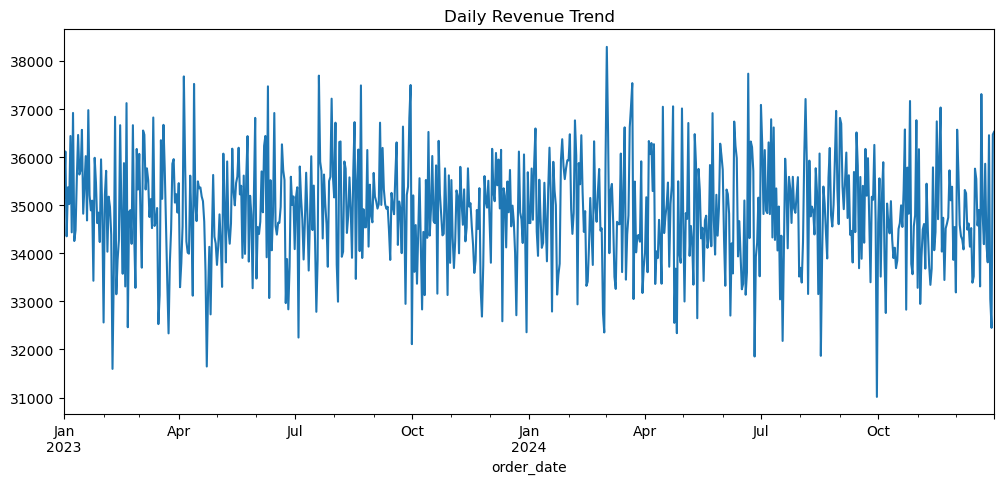

In [19]:
# Aggregate total revenue by date
daily_sales = df.groupby("order_date")["revenue"].sum()

# Plot daily revenue trend
daily_sales.plot(figsize=(12,5), title="Daily Revenue Trend")

<Axes: title={'center': 'Revenue by Month'}, xlabel='month'>

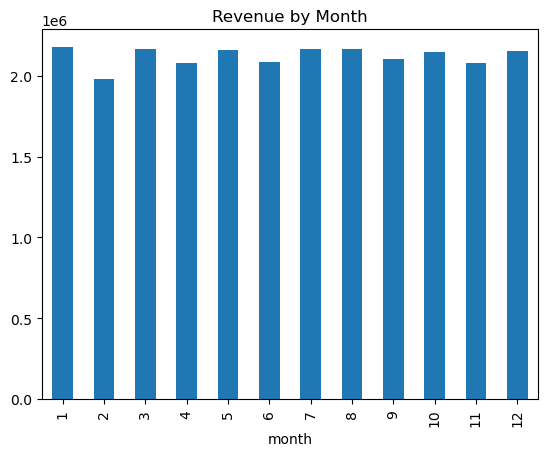

In [20]:
# Aggregate revenue by month
monthly_sales = df.groupby("month")["revenue"].sum()

# Plot monthly revenue
monthly_sales.plot(kind="bar", title="Revenue by Month")

<Axes: title={'center': 'Top 10 Products by Revenue'}, ylabel='product_name'>

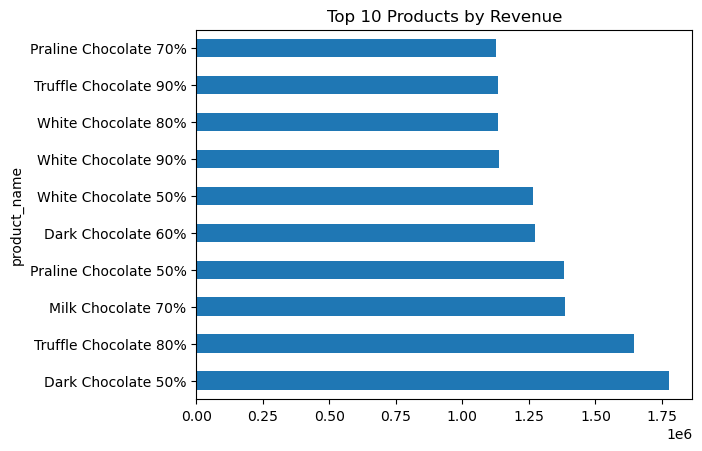

In [21]:
# Identify top-performing products by total revenue
top_products = df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10)

# Plot top products
top_products.plot(kind="barh", title="Top 10 Products by Revenue")

<Axes: title={'center': 'Average Revenue by Age'}, xlabel='age'>

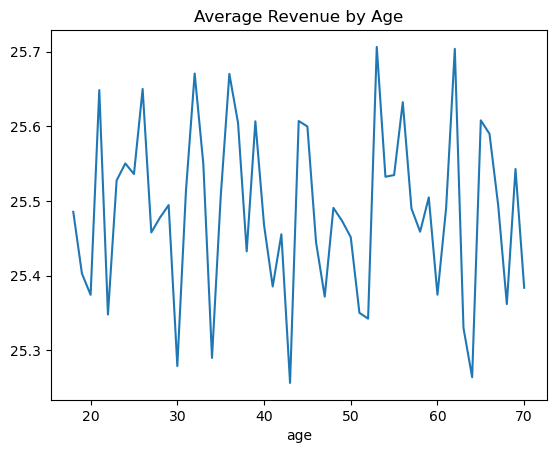

In [22]:
# Analyze average revenue by age group
df.groupby("age")["revenue"].mean().plot(title="Average Revenue by Age")

<Axes: title={'center': 'Revenue by Loyalty Membership'}, xlabel='loyalty_member'>

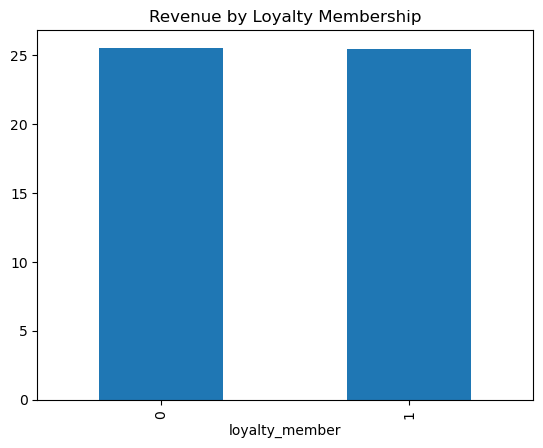

In [23]:
# Compare revenue between loyalty and non-loyalty customers
df.groupby("loyalty_member")["revenue"].mean().plot(kind="bar", title="Revenue by Loyalty Membership")

<Axes: title={'center': 'Revenue by Country'}, xlabel='country'>

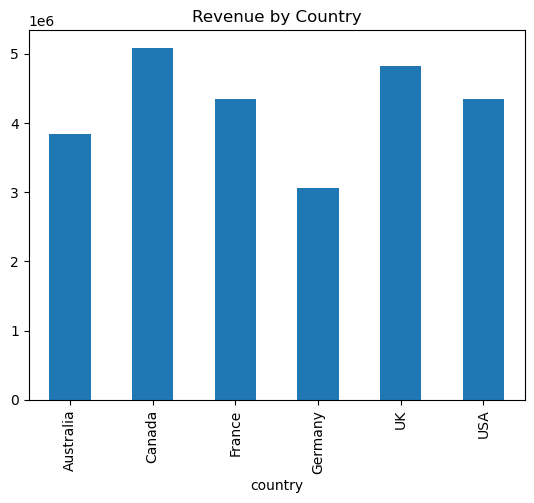

In [24]:
# Analyze revenue by country
df.groupby("country")["revenue"].sum().plot(kind="bar", title="Revenue by Country")

<Axes: >

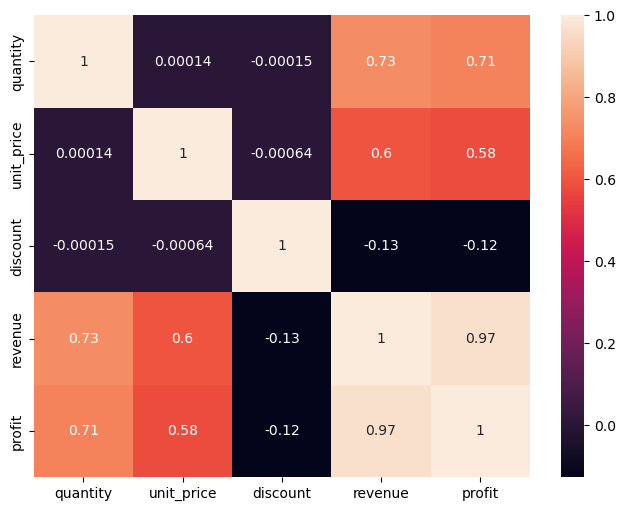

In [25]:
# Compute correlation matrix for key numerical variables
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[["quantity","unit_price","discount","revenue","profit"]].corr(), annot=True)

In [ ]:
# Select features for clustering without considering NaN produced from unmatched join in merging
features = df[["age", "quantity", "revenue"]].dropna()

# Standardize features to ensure equal scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Apply KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(X)

Text(0.5, 1.0, 'Customer Segmentation using KMeans')

C:\Users\docld\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\docld\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


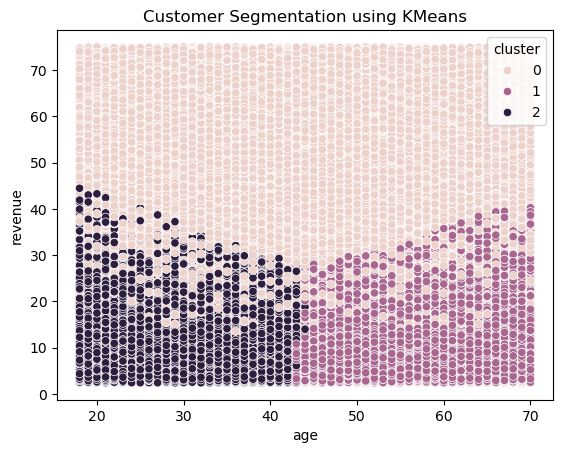

In [27]:
# Visualize clustering results
sns.scatterplot(x=features["age"], y=features["revenue"], hue=features["cluster"])
plt.title("Customer Segmentation using KMeans")

In [ ]:
# Select numerical features without considering NaN produced from unmatched join in merging
features = df[[
    "age",
    "quantity",
    "revenue",
    "unit_price",
    "discount",
    "profit"
]].dropna()

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

Text(0.5, 1.0, 'PCA Projection of Customer Behavior')

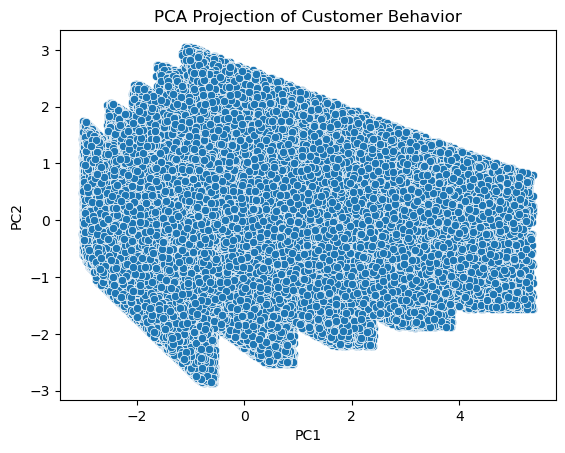

In [32]:
sns.scatterplot(x="PC1", y="PC2", data=pca_df)

plt.title("PCA Projection of Customer Behavior")

In [33]:
# Show how each feature contributes to PC1 and PC2
loadings = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=["PC1", "PC2"]
)

print("PCA Loadings:")
print(loadings)

# Show how much variance each component explains
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA Loadings:
          age  quantity   revenue  unit_price  discount    profit
PC1 -0.000388  0.440471  0.582345    0.359696 -0.076617  0.575854
PC2  0.694661  0.459603  0.000318   -0.527449  0.167357  0.000323

Explained Variance Ratio:
[0.48291009 0.16678032]


## 3. Feature Engineering & Preprocessing

In [37]:
# Remove rows with NaN produced from unmatched join in merging
df_model = df.dropna(subset=["product_name", "category", "brand"]).copy()
print("Shape after removing unmatched product rows:", df_model.shape)

# Extract target variable BEFORE any scaling to preserve interpretability (dollar units)
y = df_model["revenue"].copy()
print("\nTarget variable 'revenue' extracted before scaling. Statistics:")
print(y.describe().round(2))

Shape after removing unmatched product rows: (990236, 30)


In [ ]:
# Extract time-based features from order_date
df_model["year"] = df_model["order_date"].dt.year
df_model["month"] = df_model["order_date"].dt.month
df_model["day"] = df_model["order_date"].dt.day
df_model["day_of_week"] = df_model["order_date"].dt.dayofweek

# Additional temporal features to capture seasonality and behavioral patterns
df_model["quarter"] = df_model["order_date"].dt.quarter
df_model["is_weekend"] = (df_model["day_of_week"] >= 5).astype(int)

def get_season(month):
    if month in [12, 1, 2]:   return "Winter"
    elif month in [3, 4, 5]:  return "Spring"
    elif month in [6, 7, 8]:  return "Summer"
    else:                     return "Fall"

df_model["season"] = df_model["month"].apply(get_season)

# Customer tenure: how long the customer had been a loyalty member at the time of purchase
df_model["customer_tenure_days"] = (
    df_model["order_date"] - df_model["join_date"]
).dt.days.clip(lower=0)   # clip negatives (join_date > order_date edge cases)

print("Time features extracted. Sample:")
print(df_model[["year", "month", "quarter", "is_weekend", "season", "customer_tenure_days"]].head())

In [ ]:
# Create business-related features — all computed WITHOUT using the target (revenue)
# to prevent data leakage

# Effective price per unit: what the customer actually pays after discount
df_model["effective_price"] = df_model["unit_price"] * (1 - df_model["discount"])

# Absolute discount value per unit (monetary magnitude of the promotion applied)
df_model["discount_amount"] = df_model["unit_price"] * df_model["discount"]

# Binary flag: whether any discount was applied to this transaction
df_model["is_discounted"] = (df_model["discount"] > 0).astype(int)

# Product value density: price per gram — proxy for quality tier / premium positioning
df_model["price_per_gram"] = df_model["unit_price"] / df_model["weight_g"]

# Customer age group (binned) for richer demographic segmentation
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-70"]
).astype(str)

print("Business features created. Sample:")
print(df_model[["effective_price", "discount_amount", "is_discounted",
                 "price_per_gram", "age_group"]].head())

In [ ]:
# Drop columns that cause data leakage or carry no predictive value

# Leaky columns: 'profit' is directly derived from revenue (profit = revenue - cost)
# Including it as a feature would allow the model to trivially recover the target
leaky_cols = ["profit"]
df_model = df_model.drop(columns=leaky_cols)

# Drop identifiers, raw date columns (features already extracted), and
# high-cardinality string columns that cannot be meaningfully one-hot encoded
drop_cols = [
    "order_id",      # unique transaction ID — no generalisable signal
    "product_id",    # replaced by 'brand' and 'category'
    "store_id",      # replaced by 'store_type' and 'country'
    "customer_id",   # replaced by demographic features
    "order_date",    # temporal features already extracted
    "join_date",     # replaced by 'customer_tenure_days'
    "date",          # duplicate of order_date from the calendar merge
    "product_name",  # ~200 unique values; brand + category are sufficient
    "store_name",    # identifier-like; store_type + country capture the signal
    "city",          # high cardinality (~many cities); country is sufficient
    "revenue",       # TARGET — already extracted as y before any transformation
]
df_model = df_model.drop(columns=drop_cols)

print("Remaining columns after dropping leaky / irrelevant variables:")
print(list(df_model.columns))
print("\nShape:", df_model.shape)

In [ ]:
# Encode all categorical variables using one-hot encoding
# drop_first=True removes one category per variable to avoid perfect multicollinearity
cat_cols = ["category", "brand", "store_type", "country", "gender", "season", "age_group"]

df_model = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True
)

print("Shape after one-hot encoding:", df_model.shape)
print("Feature columns (first 20):", list(df_model.columns[:20]))

In [41]:
# Standardise numerical features using StandardScaler (zero mean, unit variance)
# The target variable (revenue) has already been extracted and is NOT scaled here.
# Binary/flag columns are excluded from scaling as they are already on [0,1] scale.
from sklearn.preprocessing import StandardScaler

binary_cols = ["loyalty_member", "is_weekend", "is_discounted"]
num_cols = [
    c for c in df_model.select_dtypes(include=["int64", "float64"]).columns
    if c not in binary_cols
]

scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

print(f"Standardised {len(num_cols)} numerical features:")
print(num_cols)

In [42]:
# Define feature matrix X and target vector y
# X contains all remaining columns (revenue already removed in the drop step)
# y was extracted before any transformation — values are in original dollar units
X = df_model.copy()

print("Feature matrix X shape:", X.shape)
print("Target vector y shape (original revenue $):", y.shape)
print("\nTarget y statistics (original scale, not standardised):")
print(y.describe().round(2))
print("\nFeature columns:", list(X.columns))

### Justification of Feature Engineering and Preprocessing Choices

This section describes the full preprocessing and feature engineering pipeline applied to prepare the data for supervised modeling.

#### 1. Missing Value Handling
Rows with unmatched product information (resulting from left-join mismatches between the `sales` and `products` tables) were removed to ensure data integrity. These ~9,764 rows represent less than 1% of the dataset and were dropped before any feature construction.

#### 2. Target Variable Extraction Before Scaling
The target variable `revenue` was extracted **before** any scaling transformation. This is a critical step: if `revenue` were scaled together with the features, model predictions and evaluation metrics (e.g., RMSE, MAE) would be expressed in standardised units rather than interpretable dollar values. Extracting `y` first preserves real-world interpretability.

#### 3. Leakage Prevention
The column `profit` was removed because it is directly derived from the target: `profit = revenue − cost`. Including it as a feature would constitute **data leakage** — the model would gain access to near-perfect information about `revenue` through a trivial algebraic identity, producing unrealistically high performance metrics on training data that would not generalise to new data. Similarly, the earlier version's `price_per_unit = revenue / quantity` and `profit_margin = profit / revenue` were replaced with leak-free alternatives.

#### 4. Enriched Time-Based Features
Beyond the basic calendar fields, the following temporal features were engineered:
- **`quarter`** (1–4): captures broad seasonal purchasing trends
- **`is_weekend`** (binary): distinguishes weekday vs. weekend shopping behaviour
- **`season`** (Winter/Spring/Summer/Fall): directly encodes climatically-driven chocolate demand patterns
- **`customer_tenure_days`**: the number of days a customer had been a loyalty member at the time of purchase — a proxy for relationship depth and repeat-buyer likelihood

#### 5. Business-Driven Feature Engineering
All derived features were constructed using only information available **before** a revenue figure is known (i.e., no leakage):
- **`effective_price`** = `unit_price × (1 − discount)`: the actual per-unit price paid by the customer
- **`discount_amount`** = `unit_price × discount`: the absolute monetary value of the promotion
- **`is_discounted`** (binary): whether any promotion was applied to the transaction
- **`price_per_gram`** = `unit_price / weight_g`: a value-density proxy capturing whether a product is positioned as budget or premium
- **`age_group`** (binned): converts continuous age into meaningful demographic cohorts (18–25, 26–35, 36–45, 46–55, 56–70), allowing models to capture non-linear age effects

#### 6. Removal of Irrelevant Columns
ID columns (`order_id`, `product_id`, `store_id`, `customer_id`), raw date columns whose information has been extracted, and high-cardinality string columns (`product_name`, `store_name`, `city`) were removed. These carry no generalisable signal and would either be ignored or cause noise in tree-based models while being completely incompatible with linear models.

#### 7. Categorical Encoding
All remaining categorical variables (`category`, `brand`, `store_type`, `country`, `gender`, `season`, `age_group`) were one-hot encoded with `drop_first=True`. The `gender` column — absent from the original preprocessing — was added to the encoding pipeline. Dropping the first level avoids the **dummy variable trap** (perfect multicollinearity) which would destabilise linear and regularised models.

#### 8. Numerical Feature Standardisation
All continuous and ordinal numerical features (excluding the target `revenue` and binary indicator columns which are already on a [0, 1] scale) were standardised using `StandardScaler` (zero mean, unit variance). This is essential for:
- **Distance-based models** (e.g., KNN, SVR): prevent high-magnitude features from dominating distance calculations
- **Regularised linear models** (e.g., Ridge, Lasso): ensure penalty terms are applied equitably across features
- **Gradient-based optimisation**: accelerates convergence by avoiding elongated loss surfaces